Uma instituição de ensino ou empresa de treinamento deseja entender quais fatores estão mais relacionados ao desempenho de alunos ou colaboradores. Para isso, foi selecionada uma amostra de dados com informações sobre perfil e dedicação, contendo:

idade
renda mensal
horas de estudo
anos de experiência
desempenho

O objetivo dela é identificar quais variáveis apresentam maior associação com o desempenho, ajudando a responder perguntas como:
* pessoas que estudam mais tendem a ter melhor desempenho?
* experiência profissional está relacionada ao resultado?
* renda mensal pode estar associada ao desempenho?
* idade influencia positiva ou negativamente os resultados?

A análise de correlação pode apoiar decisões como:
* criação de programas de apoio para alunos com menor dedicação de estudo
* definição de estratégias de treinamento
* identificação de fatores mais relevantes para melhorar desempenho
* direcionamento de investimentos em capacitaçãoItem da lista
Assim, torna-se útil calcular a correlação entre os atributos do dataset para verificar a intensidade e a direção da relação linear entre eles, com foco especial na variável desempenho.

In [2]:
# ------------------------------------------------------------
# 1) IMPORTAÇÃO DAS BIBLIOTECAS
# ------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
#é uma técnica de normalização de dados usada em Ciência de Dados e Machine Learning para transformar os valores de uma variável para um intervalo específico, normalmente entre 0 e 1.

# Exibe todas as colunas do DataFrame, se necessário
pd.set_option("display.max_columns", None)

In [4]:
# ------------------------------------------------------------
# 2) LEITURA DOS DADOS
# ------------------------------------------------------------
df = pd.read_csv("dataset_correlacao.csv")

print("=== DATAFRAME ORIGINAL ===")
print(df)

print("\n=== INFORMAÇÕES GERAIS DO DATAFRAME ===")
print(df.info())

=== DATAFRAME ORIGINAL ===
    idade  renda_mensal  horas_estudo  experiencia_anos  desempenho
0      22        2500.0           2.0               1.0        58.0
1      25        3200.0           3.0               2.0        65.0
2      28        4000.0           4.0               3.0        72.0
3      30        4500.0           5.0               5.0        80.0
4      35        5200.0           4.0               8.0        85.0
5      40        6100.0           3.0              12.0        88.0
6      23        2700.0           2.0               1.0        60.0
7      27        3900.0           4.0               3.0        70.0
8      31        4700.0           5.0               6.0        82.0
9      36        5400.0           4.0               9.0        86.0
10     41        6200.0           3.0              13.0        89.0
11     24        3000.0           3.0               2.0        64.0
12     29        4200.0           4.0               4.0        75.0
13     33        5000

In [5]:
# ------------------------------------------------------------
# 3) VERIFICAÇÃO DE VALORES AUSENTES
# ------------------------------------------------------------
# isnull().sum() conta quantos valores ausentes existem em cada coluna.
# ------------------------------------------------------------

print("\n=== VALORES AUSENTES POR COLUNA ===")
print(df.isnull().sum())


=== VALORES AUSENTES POR COLUNA ===
idade               0
renda_mensal        1
horas_estudo        2
experiencia_anos    1
desempenho          1
dtype: int64


In [6]:
# ------------------------------------------------------------
# 4) TRATAMENTO DE DADOS AUSENTES PELA MÉDIA
# ------------------------------------------------------------
# Para cada coluna numérica, os valores ausentes serão preenchidos
# com a média da própria coluna.
#
# Vantagem:
# - mantém o número de registros
# - simples de aplicar em dados numéricos
# ------------------------------------------------------------

df_preenchido = df.copy()

for coluna in df_preenchido.columns:
    media_coluna = df_preenchido[coluna].mean()
    df_preenchido[coluna] = df_preenchido[coluna].fillna(media_coluna)
    print(f"Média usada para preencher '{coluna}': {media_coluna:.2f}")

print("\n=== DATAFRAME APÓS PREENCHIMENTO DOS AUSENTES ===")
print(df_preenchido)

print("\n=== VERIFICAÇÃO FINAL DE AUSENTES ===")
print(df_preenchido.isnull().sum())

Média usada para preencher 'idade': 32.27
Média usada para preencher 'renda_mensal': 4706.90
Média usada para preencher 'horas_estudo': 3.43
Média usada para preencher 'experiencia_anos': 6.72
Média usada para preencher 'desempenho': 77.62

=== DATAFRAME APÓS PREENCHIMENTO DOS AUSENTES ===
    idade  renda_mensal  horas_estudo  experiencia_anos  desempenho
0      22   2500.000000      2.000000          1.000000    58.00000
1      25   3200.000000      3.000000          2.000000    65.00000
2      28   4000.000000      4.000000          3.000000    72.00000
3      30   4500.000000      5.000000          5.000000    80.00000
4      35   5200.000000      4.000000          8.000000    85.00000
5      40   6100.000000      3.000000         12.000000    88.00000
6      23   2700.000000      2.000000          1.000000    60.00000
7      27   3900.000000      4.000000          3.000000    70.00000
8      31   4700.000000      5.000000          6.000000    82.00000
9      36   5400.000000      

In [7]:
# ------------------------------------------------------------
# 5) MEDIDAS ESTATÍSTICAS DESCRITIVAS
# ------------------------------------------------------------
# describe() calcula:
# - count  : quantidade de valores
# - mean   : média
# - std    : desvio padrão
# - min    : mínimo
# - 25%    : primeiro quartil
# - 50%    : mediana
# - 75%    : terceiro quartil
# - max    : máximo
# ------------------------------------------------------------

estatisticas = df_preenchido.describe()

print("\n=== MEDIDAS ESTATÍSTICAS DESCRITIVAS ===")
print(estatisticas)


=== MEDIDAS ESTATÍSTICAS DESCRITIVAS ===
           idade  renda_mensal  horas_estudo  experiencia_anos  desempenho
count  30.000000     30.000000     30.000000         30.000000   30.000000
mean   32.266667   4706.896552      3.428571          6.724138   77.620690
std     7.234655   1386.369865      1.186957          4.805862   11.657213
min    20.000000   2300.000000      1.000000          0.000000   53.000000
25%    27.000000   3825.000000      3.000000          3.000000   69.250000
50%    31.500000   4753.448276      3.714286          6.000000   81.500000
75%    37.750000   5750.000000      4.000000          9.750000   86.750000
max    45.000000   7000.000000      5.000000         16.000000   92.000000


In [8]:
# ------------------------------------------------------------
# 6) INTERPRETAÇÃO DAS MEDIDAS ESTATÍSTICAS
# ------------------------------------------------------------
# Aqui faremos uma interpretação simples de:
# - média
# - mediana
# - mínimo
# - máximo
# - desvio padrão
# ------------------------------------------------------------

print("\n=== INTERPRETAÇÃO DAS MEDIDAS ESTATÍSTICAS ===\n")

for coluna in df_preenchido.columns:
    media = df_preenchido[coluna].mean()
    mediana = df_preenchido[coluna].median()
    minimo = df_preenchido[coluna].min()
    maximo = df_preenchido[coluna].max()
    desvio = df_preenchido[coluna].std()

    print(f"Atributo: {coluna}")
    print(f"- Média: {media:.2f}")
    print(f"- Mediana: {mediana:.2f}")
    print(f"- Mínimo: {minimo:.2f}")
    print(f"- Máximo: {maximo:.2f}")
    print(f"- Desvio padrão: {desvio:.2f}")

    # Interpretação de média e mediana
    if media > mediana:
        print("- Interpretação: a média maior que a mediana pode indicar influência de valores altos.")
    elif media < mediana:
        print("- Interpretação: a média menor que a mediana pode indicar influência de valores baixos.")
    else:
        print("- Interpretação: média e mediana próximas sugerem distribuição mais equilibrada.")

    # Interpretação simples da dispersão
    if desvio < 5:
        print("- Variabilidade: baixa dispersão dos dados.")
    elif desvio < 15:
        print("- Variabilidade: dispersão moderada dos dados.")
    else:
        print("- Variabilidade: alta dispersão dos dados.")

    print("-" * 60)


=== INTERPRETAÇÃO DAS MEDIDAS ESTATÍSTICAS ===

Atributo: idade
- Média: 32.27
- Mediana: 31.50
- Mínimo: 20.00
- Máximo: 45.00
- Desvio padrão: 7.23
- Interpretação: a média maior que a mediana pode indicar influência de valores altos.
- Variabilidade: dispersão moderada dos dados.
------------------------------------------------------------
Atributo: renda_mensal
- Média: 4706.90
- Mediana: 4753.45
- Mínimo: 2300.00
- Máximo: 7000.00
- Desvio padrão: 1386.37
- Interpretação: a média menor que a mediana pode indicar influência de valores baixos.
- Variabilidade: alta dispersão dos dados.
------------------------------------------------------------
Atributo: horas_estudo
- Média: 3.43
- Mediana: 3.71
- Mínimo: 1.00
- Máximo: 5.00
- Desvio padrão: 1.19
- Interpretação: a média menor que a mediana pode indicar influência de valores baixos.
- Variabilidade: baixa dispersão dos dados.
------------------------------------------------------------
Atributo: experiencia_anos
- Média: 6.72
- M

In [9]:
# ------------------------------------------------------------
# 7) NORMALIZAÇÃO DOS DADOS
# ------------------------------------------------------------
# A normalização Min-Max transforma os valores para a faixa [0, 1].
#
# Fórmula:
# x_normalizado = (x - x_min) / (x_max - x_min)
#
# Parâmetro importante:
# feature_range=(0, 1) -> faixa desejada
# ------------------------------------------------------------

scaler = MinMaxScaler(feature_range=(0, 1))

dados_normalizados = scaler.fit_transform(df_preenchido)

df_normalizado = pd.DataFrame(dados_normalizados, columns=df_preenchido.columns)

print("\n=== DATAFRAME NORMALIZADO ===")
print(df_normalizado)


=== DATAFRAME NORMALIZADO ===
    idade  renda_mensal  horas_estudo  experiencia_anos  desempenho
0    0.08      0.042553      0.250000          0.062500    0.128205
1    0.20      0.191489      0.500000          0.125000    0.307692
2    0.32      0.361702      0.750000          0.187500    0.487179
3    0.40      0.468085      1.000000          0.312500    0.692308
4    0.60      0.617021      0.750000          0.500000    0.820513
5    0.80      0.808511      0.500000          0.750000    0.897436
6    0.12      0.085106      0.250000          0.062500    0.179487
7    0.28      0.340426      0.750000          0.187500    0.435897
8    0.44      0.510638      1.000000          0.375000    0.743590
9    0.64      0.659574      0.750000          0.562500    0.846154
10   0.84      0.829787      0.500000          0.812500    0.923077
11   0.16      0.148936      0.500000          0.125000    0.282051
12   0.36      0.404255      0.750000          0.250000    0.564103
13   0.52      0.

In [10]:
# ------------------------------------------------------------
# 8) CÁLCULO DA MATRIZ DE CORRELAÇÃO
# ------------------------------------------------------------
# corr() calcula a correlação de Pearson entre todas as variáveis.
#
# O coeficiente varia entre -1 e 1:
# - 1  : correlação positiva perfeita
# - 0  : ausência de correlação linear
# - -1 : correlação negativa perfeita
# ------------------------------------------------------------

correlacao = df_preenchido.corr(method="pearson")

print("\n=== MATRIZ DE CORRELAÇÃO DE PEARSON ===")
print(correlacao)


=== MATRIZ DE CORRELAÇÃO DE PEARSON ===
                     idade  renda_mensal  horas_estudo  experiencia_anos  \
idade             1.000000      0.994766      0.141119          0.984661   
renda_mensal      0.994766      1.000000      0.219057          0.973002   
horas_estudo      0.141119      0.219057      1.000000          0.039635   
experiencia_anos  0.984661      0.973002      0.039635          1.000000   
desempenho        0.958570      0.975007      0.394765          0.916517   

                  desempenho  
idade               0.958570  
renda_mensal        0.975007  
horas_estudo        0.394765  
experiencia_anos    0.916517  
desempenho          1.000000  


In [11]:
# ------------------------------------------------------------
# 9) INTERPRETAÇÃO AUTOMÁTICA DAS CORRELAÇÕES
# ------------------------------------------------------------
# Classificação da intensidade (valor absoluto de r):
# 0.00 a 0.19 -> muito fraca
# 0.20 a 0.39 -> fraca
# 0.40 a 0.69 -> moderada
# 0.70 a 0.89 -> forte
# 0.90 a 1.00 -> muito forte
# ------------------------------------------------------------

print("\n=== INTERPRETAÇÃO DAS CORRELAÇÕES ENTRE OS ATRIBUTOS ===\n")

colunas = correlacao.columns

for i in range(len(colunas)):
    for j in range(i + 1, len(colunas)):
        var1 = colunas[i]
        var2 = colunas[j]
        r = correlacao.loc[var1, var2]
        r_abs = abs(r)

        print(f"{var1} x {var2} = {r:.3f}")

        if r_abs < 0.20:
            intensidade = "muito fraca"
        elif r_abs < 0.40:
            intensidade = "fraca"
        elif r_abs < 0.70:
            intensidade = "moderada"
        elif r_abs < 0.90:
            intensidade = "forte"
        else:
            intensidade = "muito forte"

        if r > 0:
            print(f"- Interpretação: correlação positiva {intensidade}.")
            print("- Em geral, quando uma variável aumenta, a outra também tende a aumentar.")
        elif r < 0:
            print(f"- Interpretação: correlação negativa {intensidade}.")
            print("- Em geral, quando uma variável aumenta, a outra tende a diminuir.")
        else:
            print("- Interpretação: ausência de correlação linear.")

        print("-" * 60)


=== INTERPRETAÇÃO DAS CORRELAÇÕES ENTRE OS ATRIBUTOS ===

idade x renda_mensal = 0.995
- Interpretação: correlação positiva muito forte.
- Em geral, quando uma variável aumenta, a outra também tende a aumentar.
------------------------------------------------------------
idade x horas_estudo = 0.141
- Interpretação: correlação positiva muito fraca.
- Em geral, quando uma variável aumenta, a outra também tende a aumentar.
------------------------------------------------------------
idade x experiencia_anos = 0.985
- Interpretação: correlação positiva muito forte.
- Em geral, quando uma variável aumenta, a outra também tende a aumentar.
------------------------------------------------------------
idade x desempenho = 0.959
- Interpretação: correlação positiva muito forte.
- Em geral, quando uma variável aumenta, a outra também tende a aumentar.
------------------------------------------------------------
renda_mensal x horas_estudo = 0.219
- Interpretação: correlação positiva fraca.
- E

In [13]:
# ------------------------------------------------------------
# 10) FOCO NA CORRELAÇÃO COM A VARIÁVEL DE INTERESSE: desempenho
# ------------------------------------------------------------
# Como o objetivo de negócio é entender fatores associados ao
# desempenho, vamos destacar apenas as correlações com essa variável.
# ------------------------------------------------------------

print("\n=== CORRELAÇÃO DOS ATRIBUTOS COM 'desempenho' ===\n")

variavel_alvo = "desempenho"

for coluna in correlacao.columns:
    if coluna != variavel_alvo:
        r = correlacao.loc[coluna, variavel_alvo]
        r_abs = abs(r)

        print(f"{coluna} x {variavel_alvo} = {r:.3f}")

        if r_abs < 0.20:
            intensidade = "muito fraca"
        elif r_abs < 0.40:
            intensidade = "fraca"
        elif r_abs < 0.70:
            intensidade = "moderada"
        elif r_abs < 0.90:
            intensidade = "forte"
        else:
            intensidade = "muito forte"

        if r > 0:
            print(f"- Interpretação: correlação positiva {intensidade}.")
        elif r < 0:
            print(f"- Interpretação: correlação negativa {intensidade}.")
        else:
            print("- Interpretação: ausência de correlação linear.")

        print("-" * 50)


=== CORRELAÇÃO DOS ATRIBUTOS COM 'desempenho' ===

idade x desempenho = 0.959
- Interpretação: correlação positiva muito forte.
--------------------------------------------------
renda_mensal x desempenho = 0.975
- Interpretação: correlação positiva muito forte.
--------------------------------------------------
horas_estudo x desempenho = 0.395
- Interpretação: correlação positiva fraca.
--------------------------------------------------
experiencia_anos x desempenho = 0.917
- Interpretação: correlação positiva muito forte.
--------------------------------------------------


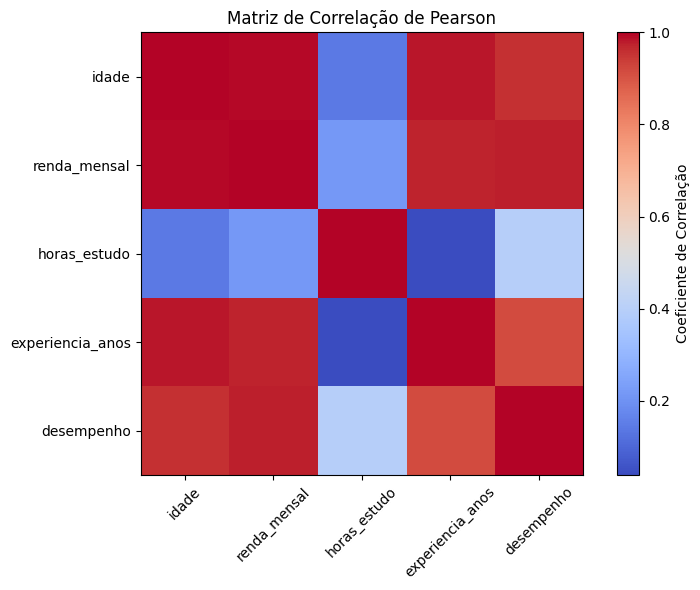

In [14]:
# ------------------------------------------------------------
# 11) VISUALIZAÇÃO DA MATRIZ DE CORRELAÇÃO
# ------------------------------------------------------------
# O mapa de calor facilita a leitura visual das relações.
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))
plt.imshow(correlacao, cmap="coolwarm", interpolation="nearest")
plt.colorbar(label="Coeficiente de Correlação")

plt.xticks(range(len(correlacao.columns)), correlacao.columns, rotation=45)
plt.yticks(range(len(correlacao.columns)), correlacao.columns)

plt.title("Matriz de Correlação de Pearson")
plt.tight_layout()
plt.show()

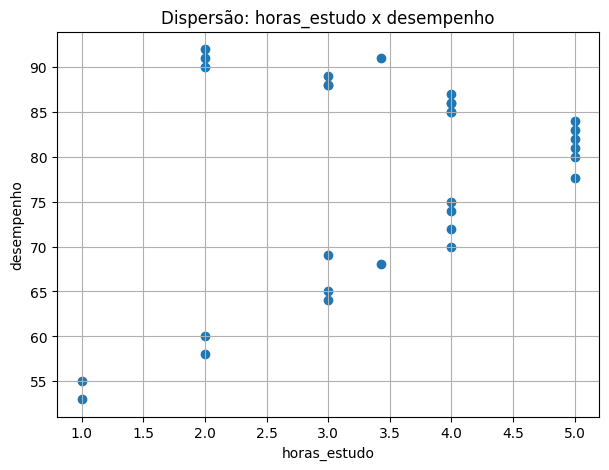

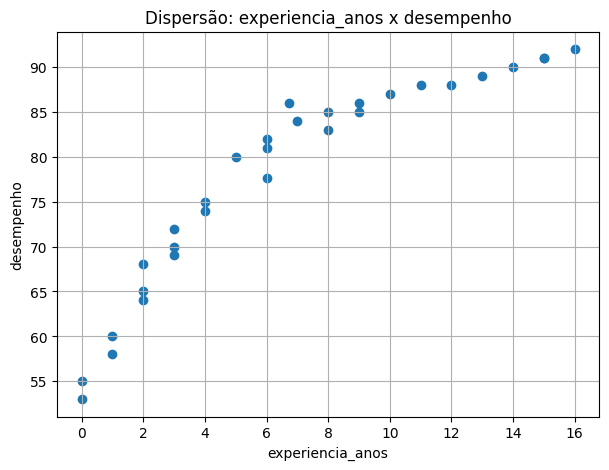

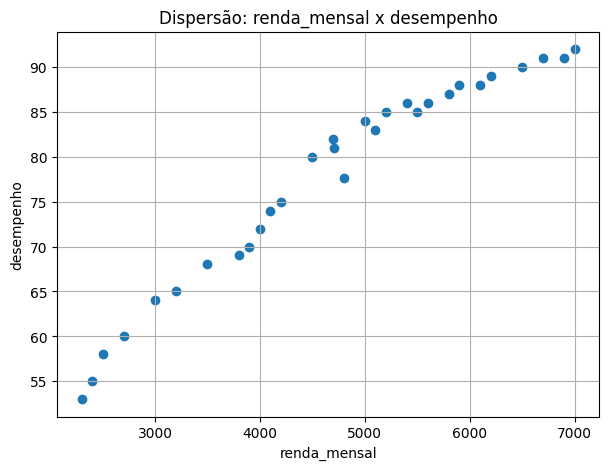

In [15]:
# ------------------------------------------------------------
# 12) GRÁFICOS DE DISPERSÃO PARA INTERPRETAÇÃO VISUAL
# ------------------------------------------------------------
# Vamos gerar alguns gráficos envolvendo a variável desempenho,
# pois ela é a variável de interesse no problema de negócio.
# ------------------------------------------------------------

pares = [
    ("horas_estudo", "desempenho"),
    ("experiencia_anos", "desempenho"),
    ("renda_mensal", "desempenho")
]

for x_col, y_col in pares:
    plt.figure(figsize=(7, 5))
    plt.scatter(df_preenchido[x_col], df_preenchido[y_col])
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title(f"Dispersão: {x_col} x {y_col}")
    plt.grid(True)
    plt.show()

In [16]:
# ------------------------------------------------------------
# 13) CONCLUSÃO AUTOMÁTICA DO PONTO DE VISTA DE NEGÓCIO
# ------------------------------------------------------------
# Este trecho identifica qual variável possui maior correlação
# (em valor absoluto) com o desempenho.
# ------------------------------------------------------------

correlacoes_desempenho = correlacao["desempenho"].drop("desempenho")
maior_correlacao = correlacoes_desempenho.abs().idxmax()
valor_maior_correlacao = correlacoes_desempenho[maior_correlacao]

print("\n=== CONCLUSÃO DO PONTO DE VISTA DE NEGÓCIO ===")
print(
    f"O atributo mais relacionado ao desempenho é '{maior_correlacao}', "
    f"com coeficiente de correlação igual a {valor_maior_correlacao:.3f}."
)

if valor_maior_correlacao > 0:
    print("Isso sugere uma relação positiva: quanto maior esse atributo, maior tende a ser o desempenho.")
elif valor_maior_correlacao < 0:
    print("Isso sugere uma relação negativa: quanto maior esse atributo, menor tende a ser o desempenho.")
else:
    print("Isso sugere ausência de relação linear relevante.")


=== CONCLUSÃO DO PONTO DE VISTA DE NEGÓCIO ===
O atributo mais relacionado ao desempenho é 'renda_mensal', com coeficiente de correlação igual a 0.975.
Isso sugere uma relação positiva: quanto maior esse atributo, maior tende a ser o desempenho.
